This notebook is better than the non-updated version, which uses an approximated PDF that blows up at low frequency and overinflates the PSF.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.io import fits
from scipy import special
from scipy import integrate

In [ ]:
wav_SunCET = 185        # SunCET wavelength (Å). Parameters below are for this wavelength.
wav_SunCET_mm = wav_SunCET / 1e7 # Wavelength in mm, to make proper spatial frequencies.

In [ ]:
# From Martinez-Galarce 2010 for SUVI
A = 610.322
B = 120
C = 1.089
K = 1. / (2 * np.sqrt(np.pi)) * special.gamma((C + 1.) / 2.) / special.gamma(C / 2.)
frequency_regions = np.array((0.02,0.25,6,700,50000))
sigma_paper = np.array((3.2999,3.3208,3.4133,2.624))

In [ ]:
# Some calculations based on that paper
Nregions = len(frequency_regions)-1
sigmaspec = np.empty((Nregions))
for i in range(Nregions):
    a=frequency_regions[i]
    b=frequency_regions[i+1]
    f = 10 ** np.linspace(np.log10(a), np.log10(b), 10000)
    PSD_2D_in_region = K * (A * B) / (1 + (B * f) ** 2) ** ((C + 1) / 2)
    sigma_rel = np.sqrt(2 * np.pi * integrate.simpson(PSD_2D_in_region * f, f))
    sigmaspec[i] = sigma_rel

Max relevant frequency in mm-1: 54054.05405405405
Integrated sigma over all relevant frequencies (Å): 6.752319318031543
Total integrated scatter: 0.18971498993774083


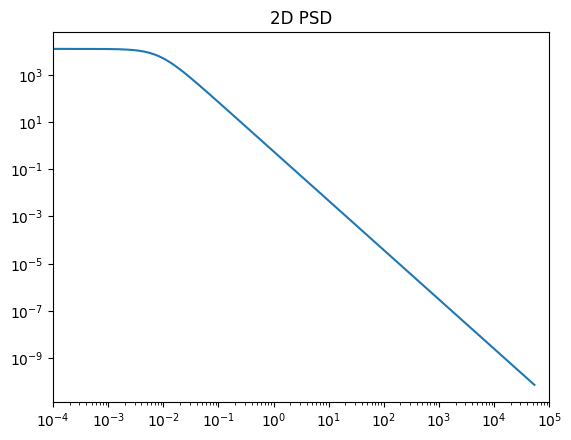

In [ ]:
# Calculate the 2D PSD
f_max = 1. / wav_SunCET_mm
print('Max relevant frequency in mm-1:', f_max)

f = 10 ** np.linspace(-100, np.log10(f_max), 10000)
PSD_2D = K * (A * B) / (1 + (B * f) ** 2) ** ((C + 1) / 2)

sigma_rel = np.sqrt(2 * np.pi * integrate.simpson(PSD_2D * f, f))
print('Integrated sigma over all relevant frequencies (Å):', sigma_rel)

TIS = 1 - np.exp(-(4 * np.pi * sigma_rel / wav_SunCET) ** 2)
print('Total integrated scatter:', TIS)

plt.plot(f, PSD_2D)
plt.title('2D PSD')
plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-4, 1e5);

In [ ]:
# For the present problem, I am most interested in Region 2, and 195 Å scattering, so
# I'll give explicit names to the relevant quantities:
fa = frequency_regions[2]      # Lower end of frequency range (1/mm)
fb = frequency_regions[3]    # Upper end of frequency range (1/mm)
sigma_ab_SunCET = sigmaspec[2]
# Just to confirm:
print('Roughness over ',fa,'/mm < f < ',fb,'/mm is ',sigma_ab_SunCET,' Å.')
sigma_ref_185_SunCET = sigma_rel # Reference roughness for 185 Å (Å)
eta_185_SunCET = TIS/8. # Total integrated scatter for 185
eta_ab_SunCET = (sigma_ab_SunCET / sigma_ref_185_SunCET)**2 * TIS # (sigma_ab_SunCET / sigma_ref_185_SunCET) * eta_185_SunCET
print('Scatter attributed to this interval: ', eta_ab_SunCET)

Roughness over  6.0 /mm < f <  700.0 /mm is  3.41328773007305  Å.
Scatter attributed to this interval:  0.04847764369686208


In [ ]:
cdelt = 4.8
rsun = 960
Nx = 2000
Ny = 1500
xmin = -(cdelt * Nx/2) / rsun
xmax = (cdelt * Nx/2) / rsun
ymin = -(cdelt * Ny/2) / rsun
ymax = (cdelt * Ny/2) / rsun
xarr = np.linspace(xmin, xmax, Nx)
yarr = np.linspace(ymin, ymax, Ny)
xarr, yarr = np.meshgrid(xarr,yarr, indexing='xy')
rarr = np.sqrt(xarr**2 + yarr**2)

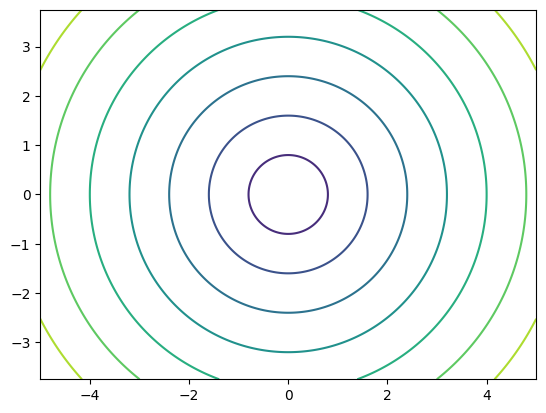

In [ ]:
plt.contour(xarr, yarr, rarr)

Roughness over  6.0 /mm < f <  700.0 /mm is  3.41328773007305  Å.
Scatter attributed to this interval:  0.04847764369686208


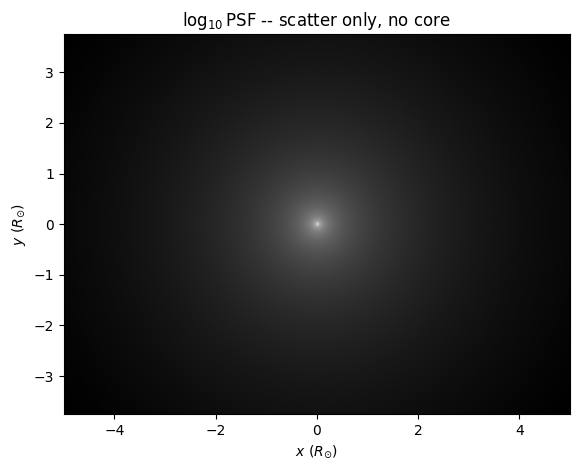

In [ ]:
# Scattering model, same units as Martínez-Galarce et al.
RMS_ref_SunCET = sigma_rel  # SunCET spec RMS roughness (Å) for sigma < wavelength.
eta_SunCET = TIS    # Total integrated scatter (TIS) for given wavelength.
# Note fa, fb, sigma_ab_SUVI, eta_ab_SUVI are inherited from the mirror model above.
print('Roughness over ',fa,'/mm < f < ',fb,'/mm is ',sigma_ab_SunCET,' Å.')
print('Scatter attributed to this interval: ', eta_ab_SunCET)

theta = rarr * 960 * (1/3600) * np.pi/180 # scattering angles in radians,
    # on same coord system as our solar image.
    # 1000 arcsec/Rsun, 1 deg/3600 arcsec, π rad / 180 deg.
frequencies = theta / wav_SunCET_mm
    # mirror spatial frequencies associated with all scattering angles (1/mm)

# We discovered that the PSF is proportional to the 1D PSD, evaluated at the appropriate frequency.
PSF_2D = np.zeros(rarr.shape)
f_img = frequencies[frequencies > 0.02]
PSF_2D[frequencies > 0.02] = K * A * B / (1 + (B * f_img) ** 2) ** ((C + 1) / 2) * theta[frequencies > 0.02]

# Normalize the theoretical PSF to match the measurements from Martinez-Galarce
dalpha = cdelt * (np.pi / 180 / 3600)          # 4.8″ in radians
dOmega_pix = dalpha**2
mask  = (frequencies >= fa) & (frequencies < fb)
PSF_sum = np.sum(PSF_2D[mask]) * dOmega_pix
normalization  = eta_new / PSF_sum
PSF_2D *= normalization


plt.figure()
plt.imshow(np.log10(PSF_2D), origin='lower', cmap='gray',
           extent=(xmin,xmax,ymin,ymax))
plt.title('$\log_{10}$PSF -- scatter only, no core')
plt.xlabel(r'$x\ (R_{\odot})$')
plt.ylabel(r'$y\ (R_{\odot})$')

plt.tight_layout()
plt.show()

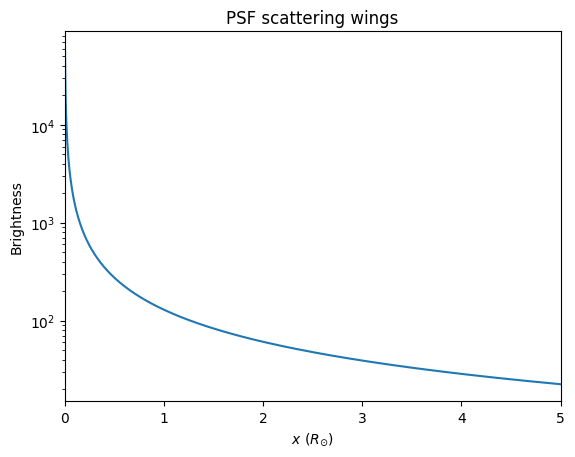

In [ ]:
r1d = rarr[Ny // 2, Nx // 2:]
PSF1d = PSF_2D[Ny // 2, Nx // 2:]

plt.figure()
plt.semilogy(r1d, PSF1d)
plt.title('PSF scattering wings')
plt.xlabel(r'$x\ (R_{\odot})$')
plt.ylabel(r'Brightness')
plt.xlim(0, 5)
plt.show()

In [ ]:
np.where(PSF == np.max(PSF))

(array([750]), array([1000]))

# Everything above was for a single mirror. Now let's consider the system with two mirrors

In [ ]:
R_secondary = 35/2     # mm
L_sep       = 80      # mm this is approximate based on a reding from Autodesk Fusion
theta_max   = R_secondary / L_sep      # radians
print(f'secondary mirror subtends a {theta_max * 180 / np.pi:.1f}º radius as perceived by primary mirror')

secondary mirror subtends a 12.5º radius as perceived by primary mirror


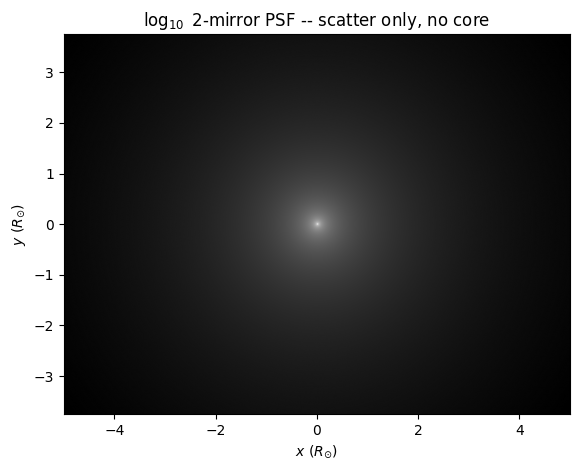

In [ ]:
# throughput mask for scatter off the PRIMARY
T_geom = (theta <= theta_max).astype(float)

# --- single-mirror scatter PSF you already built (after η_new scaling)
PSF_1mirror = PSF_2D * (eta_ab_SunCET / PSF_sum)

# --- split it into two contributions ------------------------------
PSF_primary   = PSF_1mirror * T_geom           # loses rays > θ_max
PSF_secondary = PSF_1mirror                    # same shape, no mask

# --- two-mirror single-scatter wing -------------------------------
PSF_2mirror = PSF_primary + PSF_secondary

plt.figure()
plt.imshow(np.log10(PSF_2mirror), origin='lower', cmap='gray',
           extent=(xmin,xmax,ymin,ymax))
plt.title('$\log_{10}$ 2-mirror PSF -- scatter only, no core')
plt.xlabel(r'$x\ (R_{\odot})$')
plt.ylabel(r'$y\ (R_{\odot})$')

plt.tight_layout()
plt.show()

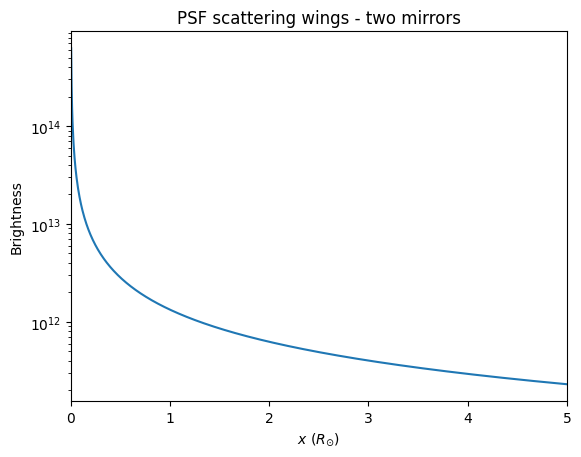

In [ ]:
r1d = rarr[Ny // 2, Nx // 2:]
PSF1d = PSF_2mirror[Ny // 2, Nx // 2:]

plt.figure()
plt.semilogy(r1d, PSF1d)
plt.title('PSF scattering wings - two mirrors')
plt.xlabel(r'$x\ (R_{\odot})$')
plt.ylabel(r'Brightness')
plt.xlim(0, 5)
plt.show()

In [ ]:
def make_header_template():
    from astropy.io import fits
    hdr = fits.Header( {
        "SIMPLE": "T",
        "BITPIX": -32,
        "NAXIS": 2,
        "NAXIS1": 2000,
        "NAXIS2": 1500,
        'WAVELNTH': 185.0, # NOTE: FITS doesn't have a keyword to store the units for wavelength, it's usually listed in the header comment instead
        'WAVEUNIT': 'Angstrom',
        'TELESCOP': 'SunCET',
        'INSTRUME': 'SunCET',
    } )
    return hdr

header = make_header_template()
hdu = fits.PrimaryHDU(PSF, header)
hdul = fits.HDUList(hdu)
hdul.writeto('suncet_mirror_scatter_psf_baffled.fits', overwrite=True)

## Do some visualazations

In [ ]:
# Model of coronal intensity

# Background fit (exponential)
def seaton_bg(elongation):
    r1  = 2.00386
    r2  = 3.49981
    bg1 = 4.50e-5
    bg2 = 2.90e-5
    h_bg = (r2-r1)/(bg2/bg1)
    A_bg = bg1 * np.exp(r1/h_bg)
    return A_bg * np.exp(-elongation/h_bg)

def seaton_corona(elongation):
    r = np.array([1.0, 1.0186, 1.04275, 1.0876, 1.14277,
                 1.24962, 1.4012, 1.55621,1.68362, 1.85574,
                 2.03811, 2.17572, 2.29268, 2.40273, 2.75697])
    sig = np.array([0.829815, 0.923365, 0.602975, 0.271197,
                    0.115656, 0.0289608, 0.00618322, 0.00139246,
                    0.000520153, 0.000189283, 9.74E-05, 6.90E-05,
                    5.73E-05, 5.16E-05, 4.07E-05])
    logcorona = np.log(sig - seaton_bg(r))
    logresult = np.interp(elongation, r, logcorona,
                          right=np.log(1e-6), left=np.log(1e-6))

    return np.exp(logresult)
    #plt.semilogy(r,sig, label='sig')
    #plt.plot(r,seaton_bg(r), label='bg')
    #plt.plot(r,sig-seaton_bg(r), label='bg-sub')
    #plt.legend()

def ck_corona(elongation, lapse=16):
    """
    Coronal brightness at given elongation angle, assuming a source function that
    falls off as r^(-lapse). Normalized to maximum limb brightness.
    """
    x = np.linspace(0,4,100) # x is the line of sight integration variable.
        # reach large enough x to reach near zero intensity.
    dx = x[1]-x[0]
    x += dx/2  # midpoint method -- begin 1/2 away from the end.
    r = np.sqrt(x**2 + 1)
    norm = 2*np.sum(r**(-lapse)) * dx
    integral = np.empty(elongation.shape)
    e = np.ravel(elongation)
    i = np.ravel(integral)
    for k in range(len(e)):
        if e[k]>=1:
            r = np.sqrt(x**2 + e[k]**2)
            i[k] = 2 * np.sum(r**(-lapse)) * dx
        else:
            r = np.sqrt((x+np.sqrt(1-e[k]**2))**2 + e[k]**2)
                # x axis shifted outside the Sun.
            i[k] = np.sum(r**(-lapse)) * dx
    return integral/norm

def ck2_corona(e):
    """
    Model Seaton et al. normalized coronal brightness at elongation angle e,
    using a linear combination of two ck_corona() models with differing
    lapse rates.
    """
    return 0.9998*ck_corona(e, lapse=16) + 0.0002*ck_corona(e, lapse=4)


def ck3_corona(e):
    """
    Accelerated version of ck2_corona(). The latter is called first to
    tabulate values, and then I return interpolants for the input array.
    """
    r = np.linspace(0,10,10000)
    corona = ck2_corona(r)
    return np.interp(e, r, corona, right=0, left=0)

r = np.linspace(0,4,1000)
coronar = seaton_corona(r) # 1D corona to plot

In [ ]:
# Simulated coronal image
xmin = -Nx/2 * cdelt / 960.
#xmin = -Nx/2 * cdelt / 960.

xy = np.linspace(xmin, xmax, Nx)
xarr, yarr = np.meshgrid(xy,xy, indexing='xy')
xarr = xarr[250:-250, :]
yarr = yarr[250:-250, :]

rarr = np.sqrt(xarr**2 + yarr**2)

%time corona = ck3_corona(rarr)

CPU times: user 142 ms, sys: 1.68 ms, total: 144 ms
Wall time: 144 ms


In [ ]:
### CONVOLUTION WITH THE CORONA ###
def pad(image):
    (Nx,Ny) = image.shape
    padded = np.zeros((2*Nx, 2*Ny))
    padded[0:Nx, 0:Ny] = image
    return padded

def unpad(padded):
    (Nx,Ny) = padded.shape
    image = padded[0:Nx//2, 0:Ny//2]
    return image

# FFT PSF for convolution
fPSF_padded = np.absolute( np.fft.fft2(pad(PSF)) )
    # Since the PSF is symmetric, the np.absolute() centers it on the origin.
fcorona_padded = np.fft.fft2(pad(corona))

background = unpad( np.real(np.fft.ifft2(fPSF_padded*fcorona_padded)) )

In [ ]:
print(background.shape)

(1500, 2000)


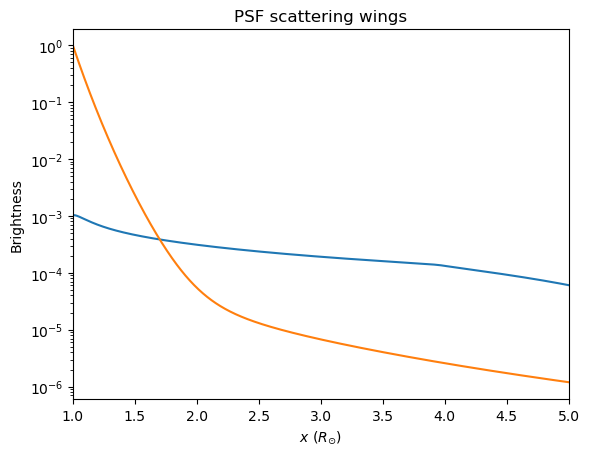

In [ ]:
r1d = rarr[Ny // 2, Nx // 2:]
BG1d = background[Ny // 2, Nx // 2:]
Cor1d = corona[Ny // 2, Nx // 2:]

plt.figure()
plt.semilogy(r1d, BG1d, label='background')
plt.semilogy(r1d, Cor1d, label='corona')
plt.title('PSF scattering wings')
plt.xlabel(r'$x\ (R_{\odot})$')
plt.ylabel(r'Brightness')
plt.xlim(1, 5)
plt.show()